# Desafio de Visão Computacional

O objetivo principal deste projeto é o desenvolvimento de um modelo de visão computacional capaz de realizar a classificação de superfícies de vias em três categorias distintas: "asphalt", "belgian_blocks" e "offroad". O problema envolve dados provenientes de cenários reais, capturados sob condições heterogêneas de iluminação, clima e dispositivos.

## Bibliotecas e Carregamento dos Dados

In [ ]:
# @title Bibliotecas

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import hashlib
import os

In [ ]:
# @title Carregamento do Arquivo

import os
from google.colab import drive, files

# Tenta montar o drive, se falhar ou se o arquivo não estiver lá, solicita upload
try:
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    zip_path = "/content/drive/MyDrive/dataset_processed.zip" # Seu caminho original

    if not os.path.exists(zip_path):
        print("Arquivo não encontrado no Drive. Por favor, faça o upload do 'dataset_processed.zip' manualmente.")
        uploaded = files.upload()
        zip_path = list(uploaded.keys())[0]
except:
    print("Não foi possível montar o Drive. Faça o upload manual:")
    uploaded = files.upload()
    zip_path = list(uploaded.keys())[0]

# Extração padrão
!unzip -o -q "{zip_path}" -d "/content/dataset/"

train_path = "/content/dataset/dataset_processed/train"
test_path = "/content/dataset/dataset_processed/test"

Mounted at /content/drive


## Análise Exploratória dos Dados

In [ ]:
# @title Quantidade de Imagens por Conjunto e Classe

# Dataset de treino
train = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# Dataset de teste
test = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

def count_files(path):
    for root, dirs, files in os.walk(path):
        if files:
            imgs = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"File: {root} | Imagens: {len(imgs)}")

print("\nQuantidade de Imagens em: Treino")
count_files(train_path)

print("\nQuantidade de Imagens em: Teste")
count_files(test_path)

Found 900 files belonging to 3 classes.
Found 300 files belonging to 3 classes.

Quantidade de Imagens em: Treino
File: /content/dataset/dataset_processed/train/asphalt | Imagens: 655
File: /content/dataset/dataset_processed/train/offroad | Imagens: 151
File: /content/dataset/dataset_processed/train/belgian_blocks | Imagens: 94

Quantidade de Imagens em: Teste
File: /content/dataset/dataset_processed/test/asphalt | Imagens: 218
File: /content/dataset/dataset_processed/test/offroad | Imagens: 50
File: /content/dataset/dataset_processed/test/belgian_blocks | Imagens: 32


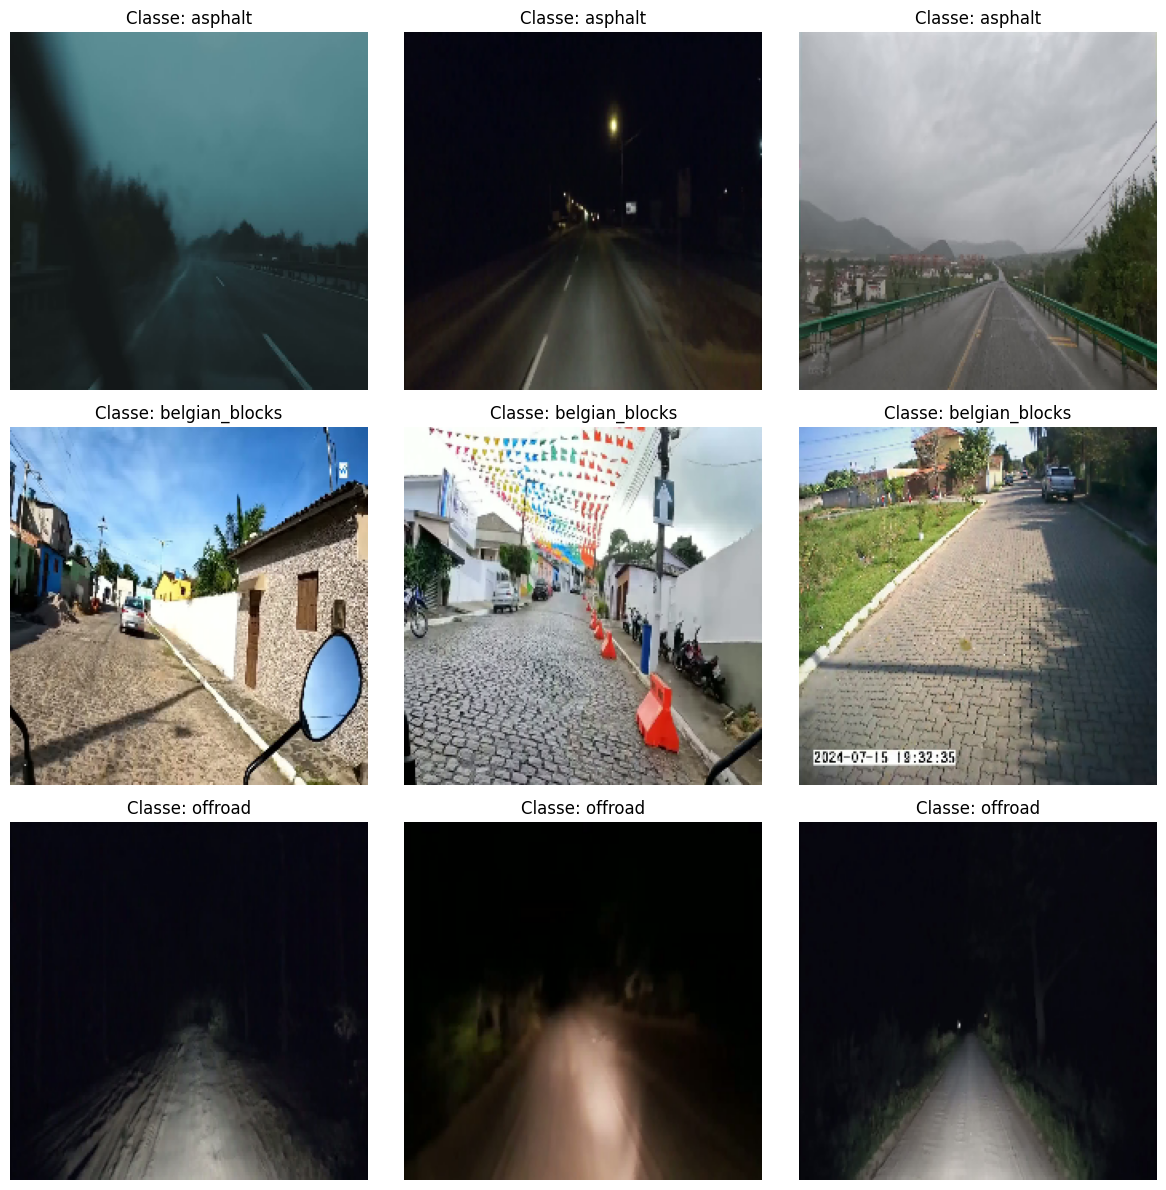

In [ ]:
# @title Visualização de Imagens

class_names = train.class_names
num_classes = len(class_names)
images_per_class = 3

plt.figure(figsize=(12, 4 * num_classes))

count_dict = {name: 0 for name in class_names}

for image, label in train.unbatch():
    idx = np.argmax(label)
    name = class_names[idx]

    if count_dict[name] < images_per_class:
        pos = (idx * images_per_class) + count_dict[name] + 1

        ax = plt.subplot(num_classes, images_per_class, pos)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(f"Classe: {name}")
        plt.axis("off")

        count_dict[name] += 1

    if all(c >= images_per_class for c in count_dict.values()):
        break

plt.tight_layout()
plt.show()

In [ ]:
# @title Dimensionalidade

for images, labels in train.take(1):
    print(f"Shape: {images.shape}")
    print(f"Tipo de dado dos pixels: {images.dtype}")
    print(f"Shape dos Labels: {labels.shape}")

    # Intervalo dos pixels
    print(f"\nValor Máximo do Pixel: {np.max(images[0])}")
    print(f"Valor Mínimo do Pixel: {np.min(images[0])}")

Shape: (32, 224, 224, 3)
Tipo de dado dos pixels: <dtype: 'float32'>
Shape dos Labels: (32, 3)

Valor Máximo do Pixel: 255.0
Valor Mínimo do Pixel: 0.0


In [ ]:
# @title Imagens Vazias e Duplicatas

# Imagens Vazias
def check_blank_images(dataset):
    blank_count = 0
    for images, _ in dataset:
        for img in images:
            if np.var(img.numpy()) == 0:
                blank_count += 1
    return blank_count

print(f"Quantidade de imagens vazias: {check_blank_images(train)}")

# Duplicatas
def find_duplicates(directory):
    hashes = {}
    duplicates = []
    for root, _, files in os.walk(directory):
        for f in files:
            path = os.path.join(root, f)
            file_hash = hashlib.md5(open(path, 'rb').read()).hexdigest()
            if file_hash in hashes:
                duplicates.append((path, hashes[file_hash]))
            else:
                hashes[file_hash] = path
    return duplicates

dups = find_duplicates(train_path)
print(f"Total de duplicatas: {len(dups)}")

Quantidade de imagens vazias: 0
Total de duplicatas: 0


Distribuição das Classes:
 - asphalt: 655 imagens (72.78%)
 - belgian_blocks: 94 imagens (10.44%)
 - offroad: 151 imagens (16.78%)

Medidas de Concentração:
Índice de Herfindahl (HHI): 0.5687
Entropia: 1.1061 bits
Índice de Simpson: 0.4313


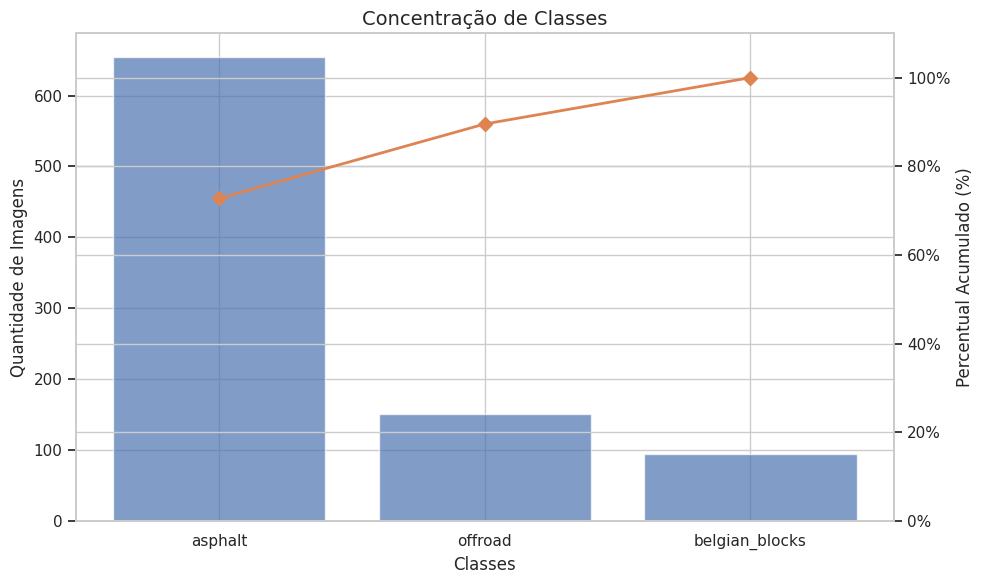

In [ ]:
# @title Análise de Concentração e Distribuição de Classes

from matplotlib.ticker import PercentFormatter

class_names = train.class_names
labels_list = []

for _, labels in train:
    labels_list.extend(np.argmax(labels.numpy(), axis=1))

total_imagens = len(labels_list)
counts_series = pd.Series(labels_list).value_counts().sort_index()
counts_series.index = [class_names[i] for i in counts_series.index]

# Medidas de Concentração
proporcoes = counts_series / total_imagens
p = proporcoes.values

# HHI
hhi = np.sum(p**2)
# Entropia
entropia = -np.sum(p * np.log2(p))
# Índice de Simpson
simpson = 1 - hhi

print(f"Distribuição das Classes:")
for name, count in counts_series.items():
    percent = (count / total_imagens) * 100
    print(f" - {name}: {count} imagens ({percent:.2f}%)")

print(f"\nMedidas de Concentração:")
print(f"Índice de Herfindahl (HHI): {hhi:.4f}")
print(f"Entropia: {entropia:.4f} bits")
print(f"Índice de Simpson: {simpson:.4f}")

# Gráfico de Concentração de Classes
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_pareto = pd.DataFrame({'Frequencia': counts_series}).sort_values(by='Frequencia', ascending=False)
df_pareto['Percent_Acumulado'] = df_pareto['Frequencia'].cumsum() / total_imagens * 100

ax1 = plt.gca()
ax1.bar(df_pareto.index, df_pareto['Frequencia'], color="C0", alpha=0.7)
ax1.set_ylabel("Quantidade de Imagens", fontsize=12)
ax1.set_xlabel("Classes", fontsize=12)

ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['Percent_Acumulado'], color="C1", marker="D", ms=7, linewidth=2)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Percentual Acumulado (%)", fontsize=12)
ax2.set_ylim(0, 110)

plt.title("Concentração de Classes", fontsize=14)
plt.tight_layout()
plt.show()

A análise de Distribuição e Concentração das classes confirmou o grande desbalancemaneto.

A interpretação é confirmada pelo Índice de Herfindahl, no qual há apresenta um desbalanceamento de poder entre as classes; como também, na Entropia e Índice de Simpson, que reforça a pouca diversidade de informação para o modelo que será treinado.

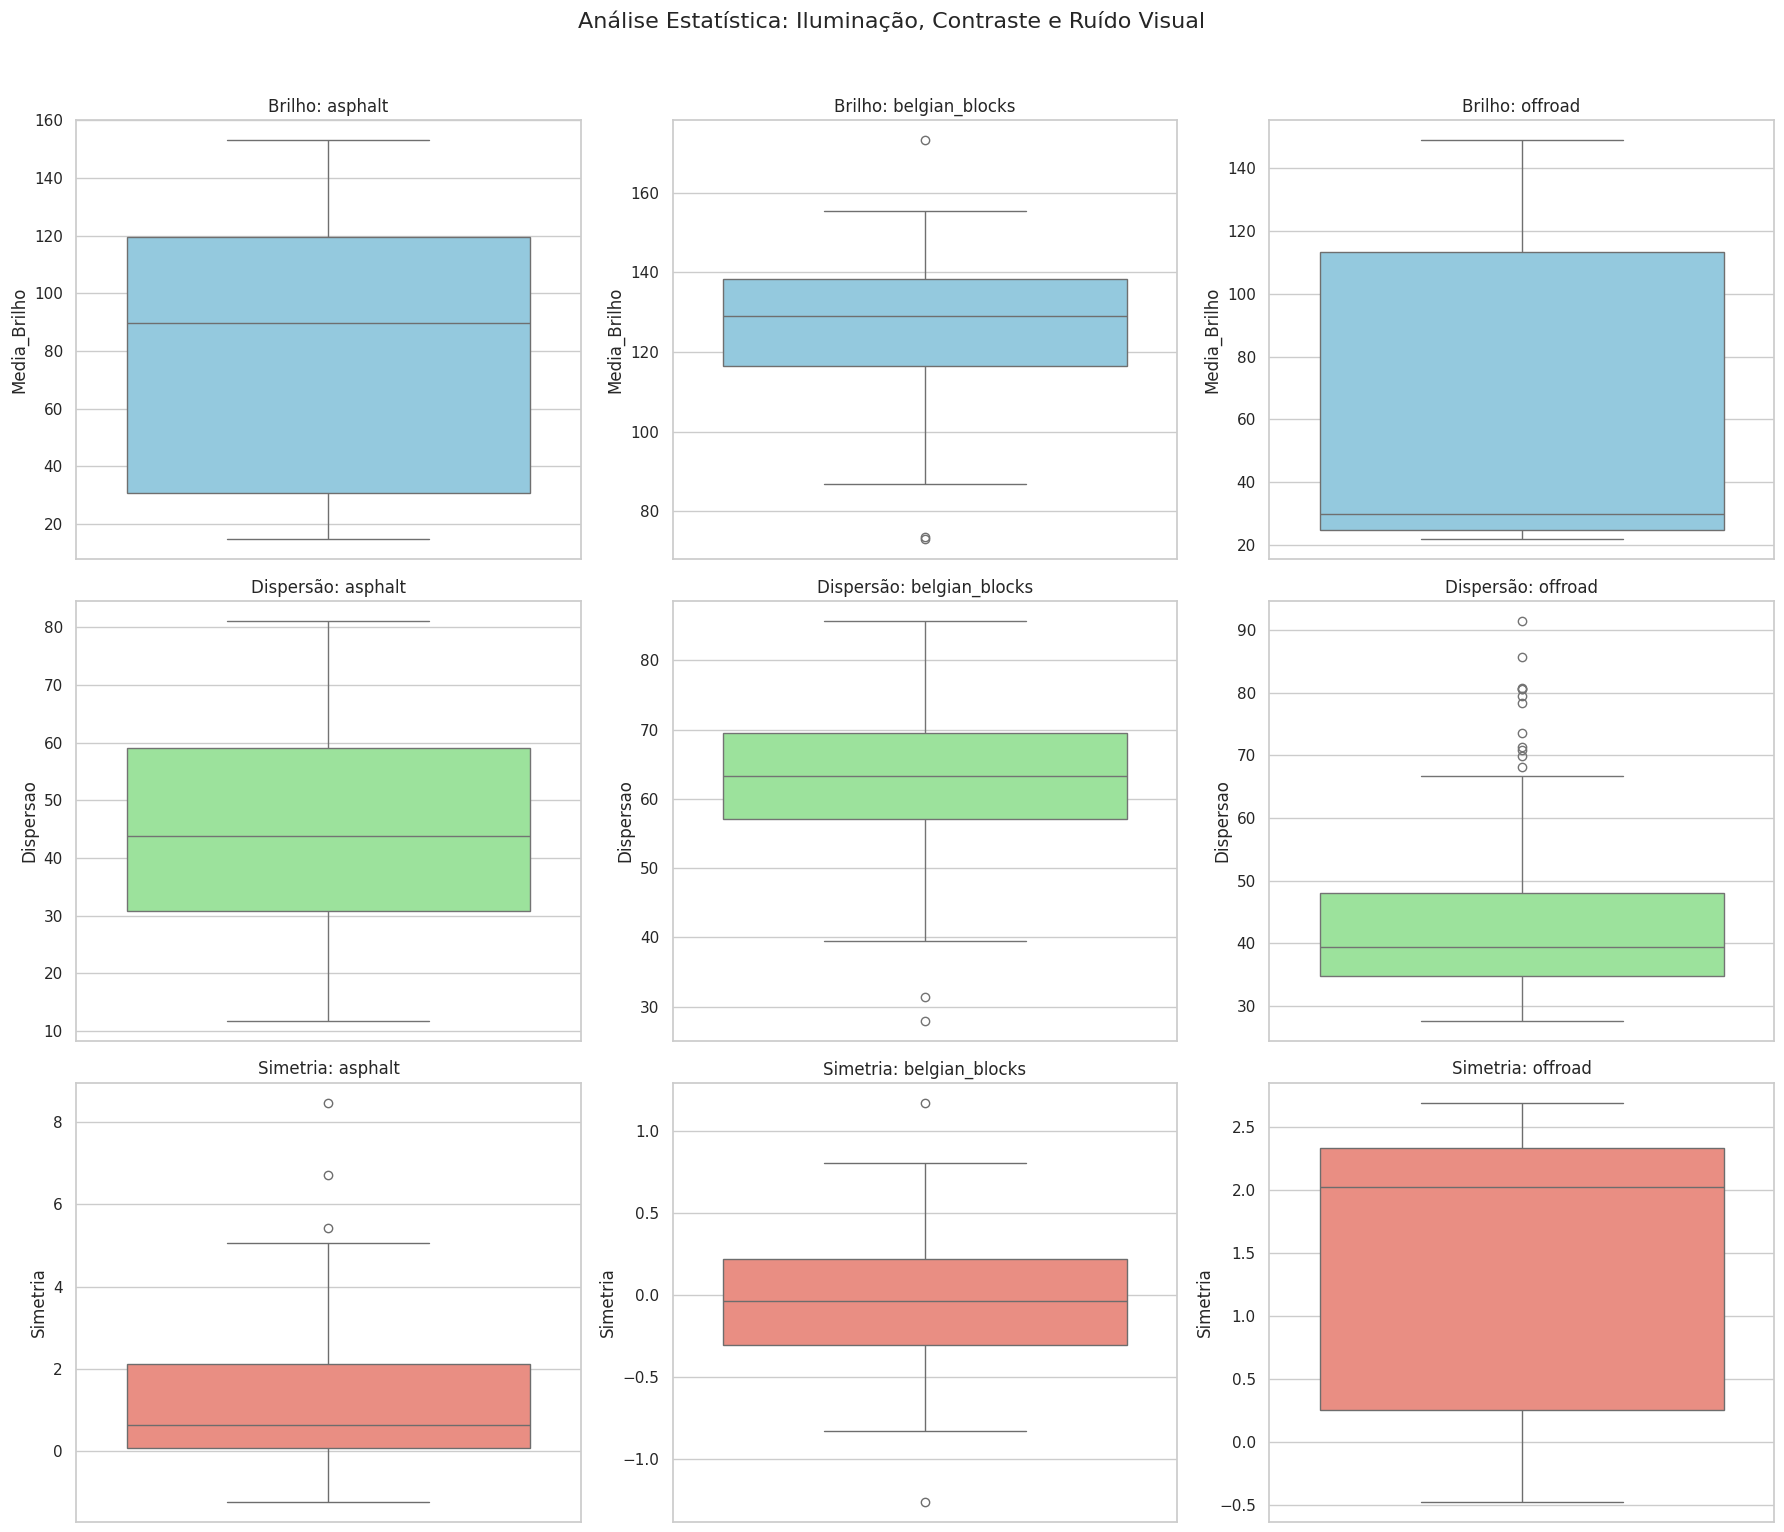

In [ ]:
# @title Análise Univariada

from scipy.stats import skew

stats = []
class_names = train.class_names

for images, labels in train.unbatch():
    img_array = images.numpy().astype("uint8")
    gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Métricas de Pixel
    mean_val = np.mean(gray_img)
    std_val = np.std(gray_img)
    skew_val = skew(gray_img.flatten())

    label_idx = np.argmax(labels.numpy())
    label_name = class_names[label_idx]

    stats.append([label_name, mean_val, std_val, skew_val])

df_stats = pd.DataFrame(stats, columns=['Classe', 'Media_Brilho', 'Dispersao', 'Simetria'])

if not df_stats.empty:
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    sns.set_theme(style="whitegrid")

    for i, classe in enumerate(class_names):
        df_classe = df_stats[df_stats['Classe'] == classe]

        if len(df_classe) > 0:
            sns.boxplot(y='Media_Brilho', data=df_classe, ax=axes[0, i], color='skyblue')
            axes[0, i].set_title(f"Brilho: {classe}")

            sns.boxplot(y='Dispersao', data=df_classe, ax=axes[1, i], color='lightgreen')
            axes[1, i].set_title(f"Dispersão: {classe}")

            sns.boxplot(y='Simetria', data=df_classe, ax=axes[2, i], color='salmon')
            axes[2, i].set_title(f"Simetria: {classe}")
        else:
            axes[0, i].set_title(f"{classe} - sem dados")

    plt.suptitle("Análise Estatística: Iluminação, Contraste e Ruído Visual", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

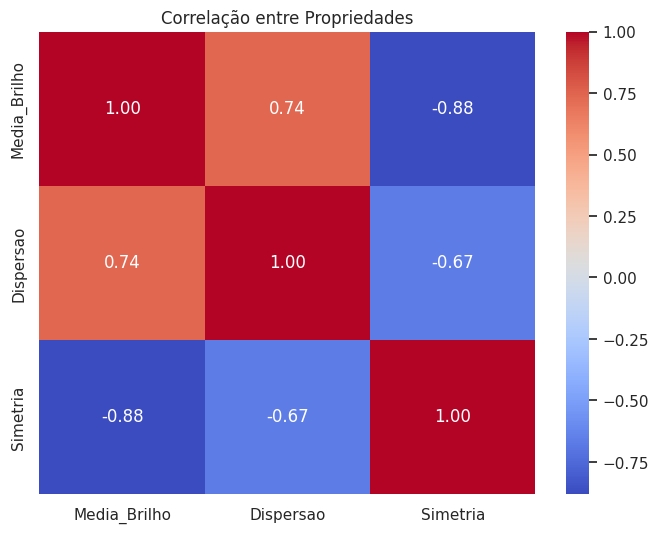

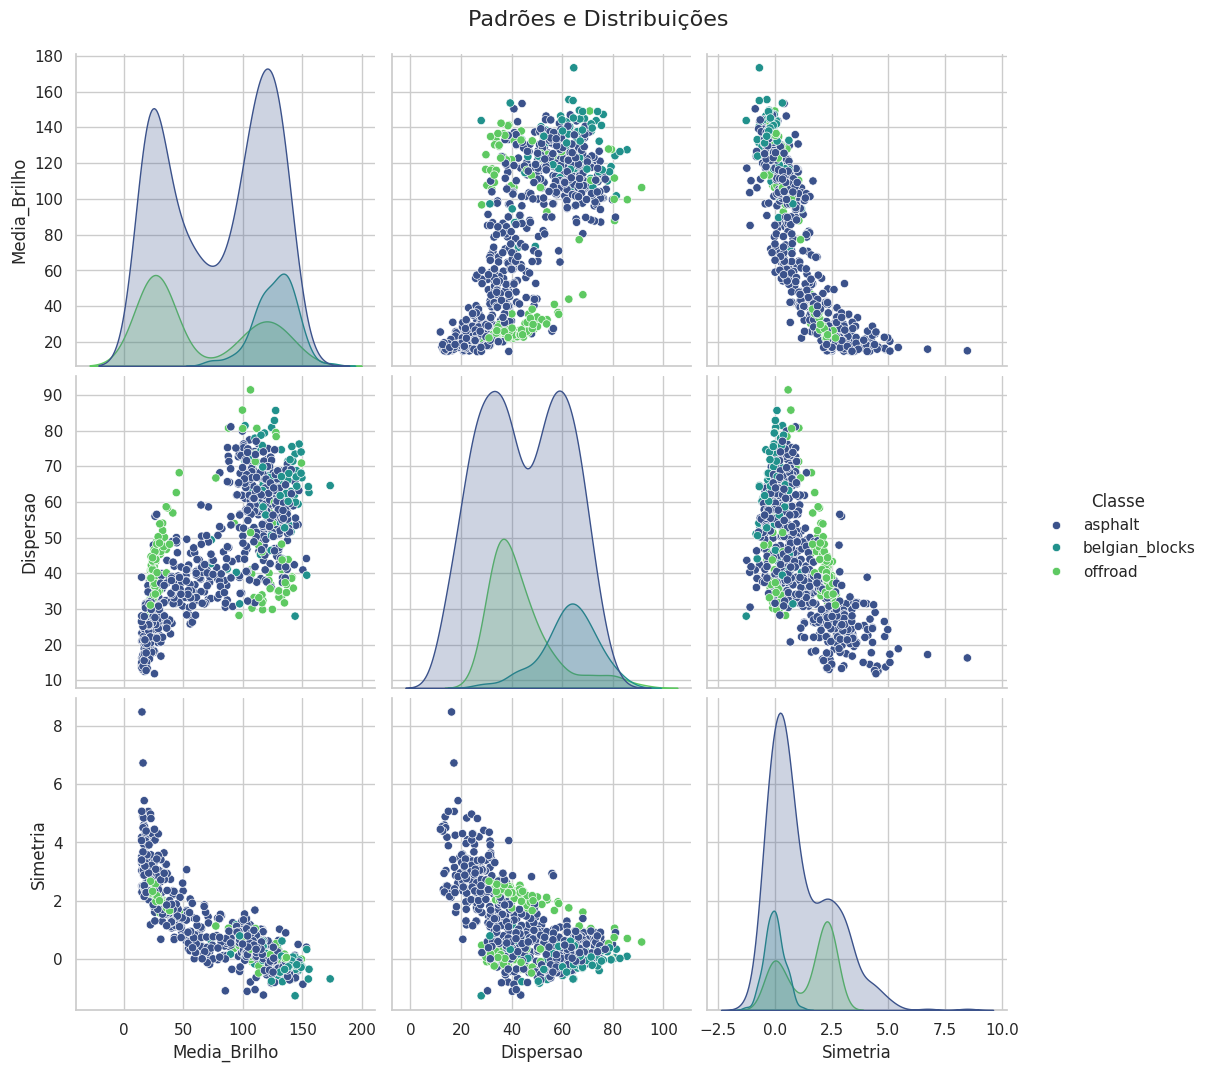

In [ ]:
# @title Análise Multivariada

# Matriz de Correlação das Métricas
plt.figure(figsize=(8, 6))
correlation = df_stats[['Media_Brilho', 'Dispersao', 'Simetria']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlação entre Propriedades")
plt.show()

# Clusters Naturais
sns.pairplot(df_stats, hue='Classe', diag_kind='kde', palette='viridis', height=3.5)
plt.suptitle("Padrões e Distribuições", y=1.02, fontsize=16)
plt.show()

- Há uma forte correlação entre as três propriedades, podendo causa multicolinearidade.

- Brilho: a classe "asphalt" possui grandes picos em luminosidade, quanto em pouca luminosidade (dia/noite); acontece em "offroad", também, mas com uma contentração maior em sombras. Já em "belgian_blocks" as imagens se concentram em luminosidade alta.

- Dispersão: "asphalt" possui constrastes bem distribuídos. "offrad" possui muito Outliers.E "belgian_blocks" tem um contraste concentrado em cima, provavelmente por causa dos blocos da superfície.

- Simetria: "asphalt" e "offroad" mostram picos próximos a 1, o que leva a um assimetria, ou seja, outliers.

- Brilho vs Simetria: à medida que a média de brilho aumento, os valores de simetria tendem a diminuir (correlação negativa). O gráfico possibilitou a detecção de Outliers nas classes "asphat" e "belgian_blocks".
- Brilho vs Dispersão: as imagens com mais iluminação tendem a apresentar maior contraste. Outliers em "belgian_blocks".
- Dispersão vs Simetria: segue a tendencia do brilho, quanto maior o contraste, menor a simetria

**2.3. Sobreposição de Classes:**
Há uma sobreposição muito pronunciada entre as classes, principalmente "asphalt" e "offroad", o que pode levar o modelo a ter dificuldade na classificação.

## Pré-processamento

In [ ]:
# @title Data Augmentation e Tratamento do Desbalanceamento

from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomBrightness(factor=0.3, value_range=(0, 255)),
    layers.RandomContrast(factor=0.3),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

def build_model():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        layers.Lambda(applications.mobilenet_v2.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

O pré-processamento foi feito voltado para o treinamento do modelo mobilenet_v2.

**Data Augmentation:**
1. Uso da técnica de aumento de dados para datasets com desbalancemaento.
2. Aplica transformações aleatórias ns imagens para: alterar a iluminação; inverter a imagem; afastar ou aproximar a imagem.

**Camada Lambda:**
Converte as imagens para uma escala menor para cálculos matemáticos.

In [ ]:
# @title Preparação de Dados para K-Fold

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

full_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=None,
    label_mode='categorical'
)

images = []
labels = []
for img, label in full_train_ds:
    images.append(img.numpy())
    labels.append(label.numpy())

X = np.array(images)
y = np.array(labels)
print(f"Total de imagens para 'validação': {len(X)}")

Found 900 files belonging to 3 classes.
Total de imagens para 'validação': 900


## Treinamento

In [ ]:
# @title Treinamento do Modelo mobilenet_v2

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
all_scores = []

for train_index, val_index in kf.split(X):
    print(f'Treinando Fold {fold_no} ')

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = build_model()

    # Treinamento
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    scores = model.evaluate(X_val, y_val, verbose=0)
    all_scores.append(scores[1])
    print(f'Acurácia Fold {fold_no}: {scores[1]*100:.2f}%')
    fold_no += 1

print(f'\nAcurácia Média Final (K-Fold): {np.mean(all_scores)*100:.2f}%')

Treinando Fold 1 
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6472 - loss: 0.9611 - val_accuracy: 0.7278 - val_loss: 0.7361
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8375 - loss: 0.4239 - val_accuracy: 0.9056 - val_loss: 0.3872
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8819 - loss: 0.3091 - val_accuracy: 0.9167 - val_loss: 0.2848
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9250 - loss: 0.2285 - val_accuracy: 0.9278 - val_loss: 0.2540
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9347 - loss: 0.2032 - val_accuracy: 0.9333 - val_loss: 0.2312
Acurácia Fold 1: 93.33%
Treinando Fold 2 
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7542 - loss: 0.6856 - val_accuracy: 0.8333 - val_loss: 0.3818
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8903 - loss: 0.3421 - val_accuracy: 0.8889 - val_loss: 0.2686
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.90

O modelo MobileNetV2 foi escolhido pelo equilíbrio entre eficiência computacional e precisão.

Utiliza Transfer Learning para aprender características mais complexas para identificar superfícies de vias.

O uso do K-Fold é importante devido a falta de um conjunto de validação.

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 758ms/step

Avaliação
                precision    recall  f1-score   support

       asphalt       0.93      0.98      0.95       655
belgian_blocks       0.91      0.72      0.80        94
       offroad       0.95      0.83      0.89       151

      accuracy                           0.93       900
     macro avg       0.93      0.84      0.88       900
  weighted avg       0.93      0.93      0.93       900



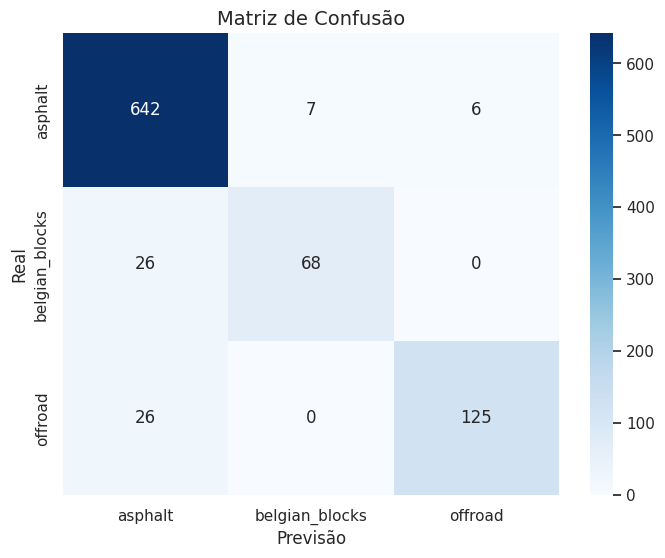

In [ ]:
# @title Métricas de Avaliação (Treino)
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X, batch_size=BATCH_SIZE)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y, axis=1)

# Avaliação
print("\nAvaliação")
report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print(report)

# Matriz de Confusão
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão', fontsize=14)
plt.xlabel('Previsão', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()

Treino vs teste
Acurácia Treino: 92.78%
Acurácia Teste:  80.00%


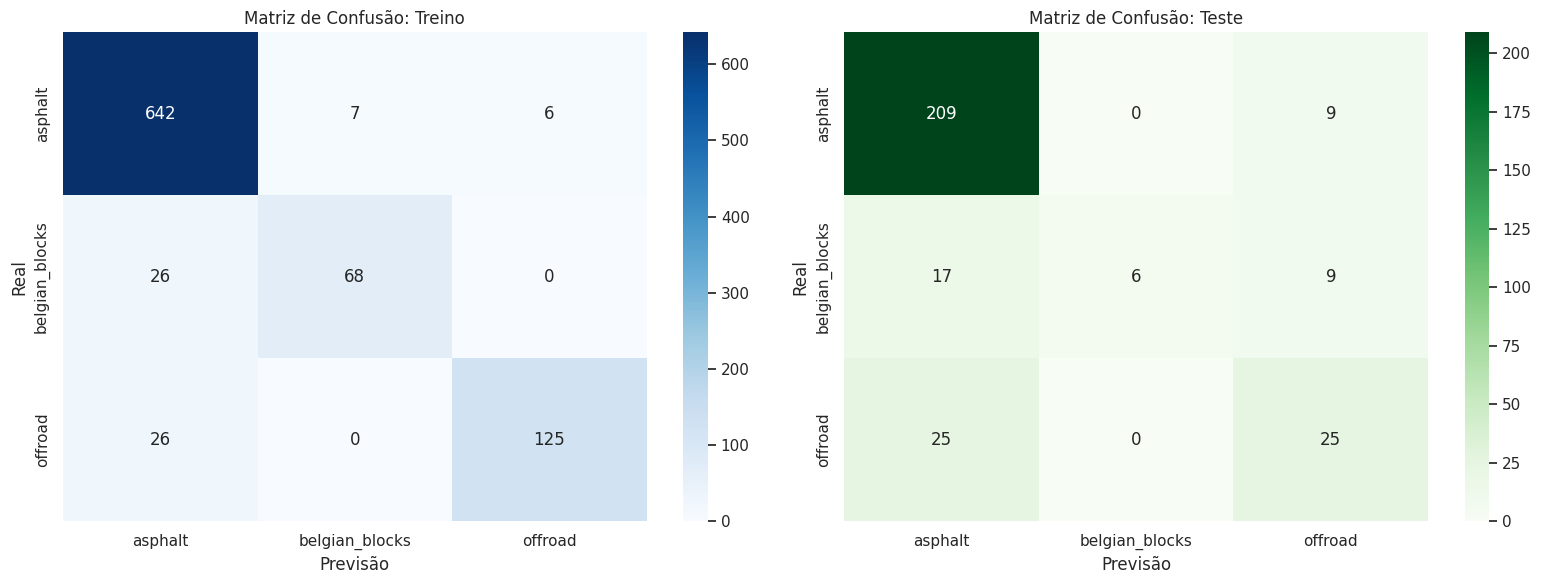


Avaliação: Teste
                precision    recall  f1-score   support

       asphalt       0.83      0.96      0.89       218
belgian_blocks       1.00      0.19      0.32        32
       offroad       0.58      0.50      0.54        50

      accuracy                           0.80       300
     macro avg       0.80      0.55      0.58       300
  weighted avg       0.81      0.80      0.77       300



In [ ]:
# @title Métricas para Comparação Treino vs Teste

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def get_predictions_and_labels(model, dataset):
    all_labels = []
    all_preds = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(all_labels), np.array(all_preds)

y_true_train, y_pred_train = get_predictions_and_labels(model, train)

y_true_test, y_pred_test = get_predictions_and_labels(model, test)

# Acurácia
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_test = accuracy_score(y_true_test, y_pred_test)

print(f"Treino vs teste")
print(f"Acurácia Treino: {acc_train*100:.2f}%")
print(f"Acurácia Teste:  {acc_test*100:.2f}%")


# Matrizes de Confusão
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Treino
cm_train = confusion_matrix(y_true_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names)
ax[0].set_title(f'Matriz de Confusão: Treino')
ax[0].set_xlabel('Previsão')
ax[0].set_ylabel('Real')

# Matriz de Teste
cm_test = confusion_matrix(y_true_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=class_names, yticklabels=class_names)
ax[1].set_title(f'Matriz de Confusão: Teste')
ax[1].set_xlabel('Previsão')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("\nAvaliação: Teste")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

A comparação das métricas de avaliação entre Treino e Teste relatam que:

- **Overfitting:** o modelo memorizou ao invés de aprender as características.
1. A acurácia caiu de 93% para 80%
2. F1-Socore caiu drasticamente em "belgian_blocks" e "offorad"
3. Decorou um padrão especpificomde "belgian_blocks", representado pela alta Precision e baixa Recall.
4. Viés da Classe "asphalt": o Recall é alto devido ao desbalancemaneto.

## Hipótese 1

**1. Hipótese e Motivação:**
A análise exploratória revelou que os dados estão divididos em dois picos opostos e alta dispersão no brilho da classe asphalt, além de uma concentração de imagens escuras e com outliers de dispersão na classe "offroad". A hipótese é que o ajuste dos parâmetros de *RandomBrightness* e *RandomContrast* para valores menores (0.2) evitará a saturação de imagens extremas, preservando as texturas finas necessárias para distinguir superfícies lisas de irregulares sob variadas condições de iluminação e ruído.

**2. O que foi modificado:** O fator de aumento de dados para brilho e contraste no pré-processamento foi reduzido de 0.3 para 0.2. Além disso, a taxa de Dropout na camada densa foi elevada de 0.2 para 0.3 para diminuir a influência dos outliers de simetria e dispersão detectados. Por causa disso, a quantidade de Épocas foi aumentada.

**3. O que foi observado:**
- Generalização: por meio da acurácia em "asphalt" (80% para 82%) e do F1-Score (0.58 para 0.64), o modelo ganha generalização.
- Desbalanceamento: o Recall em "belgian_blocks" aumentou (0.19 para 0.28).
- Estabilização de "asphalt": a detecção está quase perfeito, apesar da Precision ter diminuido (0.83 para 0.81).

**4. Interpretação:**
- A redução do fator de brilho evitou a saturação, o que explica o Recall de "asphalt".
- O aumento do Droupout atingiu a Precision de "offroad" (0.58 para 0.85) ao diminuir os efeitos dos ruídos.
- O Recall baixo espelha o problema do desbalancemanto que não foi resolvido ao alterar a iluminação das imagens.

A hipótese foi aprovada, pois as modificações trouxeram uma base mais sólida para insights futuros e refinamento no desbalanceamento de classes.

### Pré-processamento e Retreinamento

In [ ]:
# @title Pré-processamento modificado

import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from tensorflow.keras import layers, models, applications

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

full_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=None,
    label_mode='categorical'
)

images, labels = [], []
for img, label in full_train_ds:
    images.append(img.numpy())
    labels.append(label.numpy())

X = np.array(images)
y = np.array(labels)
class_names = full_train_ds.class_names

# Hipótese 1: Fatores moderados para preservar texturas finas
data_augmentation_h1 = models.Sequential([
    layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
    layers.RandomContrast(factor=0.2),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="augmentation_hipotese_1")

def build_model_h1():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation_h1,
        layers.Lambda(applications.mobilenet_v2.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        # Hipótese 1: Dropout aumentado para robustez contra outliers
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Found 900 files belonging to 3 classes.


In [ ]:
# @title Treinamento com Alterações

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
h1_scores = []

for train_index, val_index in kf.split(X):
    print(f'\nTreinando Fold {fold_no}:')

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model_h1 = build_model_h1()

    # Treinamento
    history = model_h1.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=7, # Aumentado para compensar o Dropout maior
        batch_size=BATCH_SIZE,
        verbose=1
    )

    scores = model_h1.evaluate(X_val, y_val, verbose=0)
    h1_scores.append(scores[1])
    print(f'Acurácia Fold {fold_no} (H1): {scores[1]*100:.2f}%')
    fold_no += 1

print(f'\nResultado Médio H1: {np.mean(h1_scores)*100:.2f}%')


Treinando Fold 1:
Epoch 1/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6597 - loss: 0.9316 - val_accuracy: 0.7833 - val_loss: 0.4642
Epoch 2/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8347 - loss: 0.4284 - val_accuracy: 0.8278 - val_loss: 0.3123
Epoch 3/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8708 - loss: 0.3226 - val_accuracy: 0.9111 - val_loss: 0.2079
Epoch 4/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9014 - loss: 0.2757 - val_accuracy: 0.9333 - val_loss: 0.1614
Epoch 5/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9014 - loss: 0.2501 - val_accuracy: 0.9500 - val_loss: 0.1387
Epoch 6/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9264 - loss: 0.2226 - val_accuracy: 0.9556 - val_loss: 0.1288
Epoch 7/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9375 - loss: 0.1868 - val_accuracy: 0.9444 - val_loss: 0.1353
Acurácia Fold 1 (H1): 94.44%

Treinando Fold 2:
Epoch 1/7
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accurac

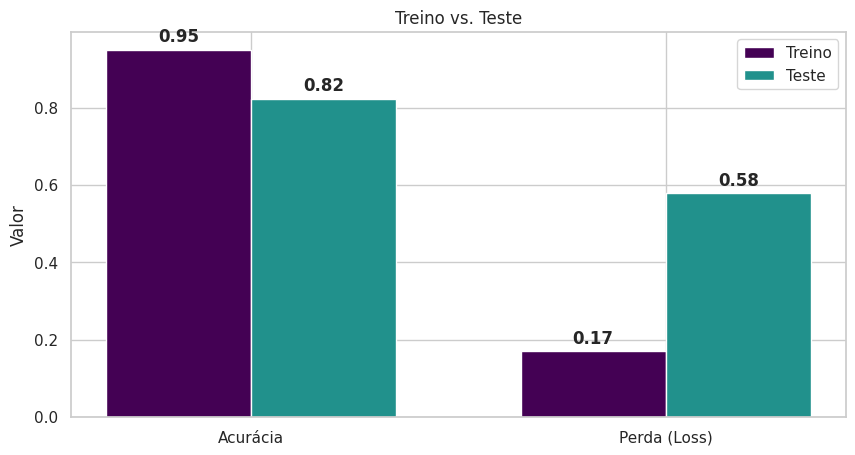

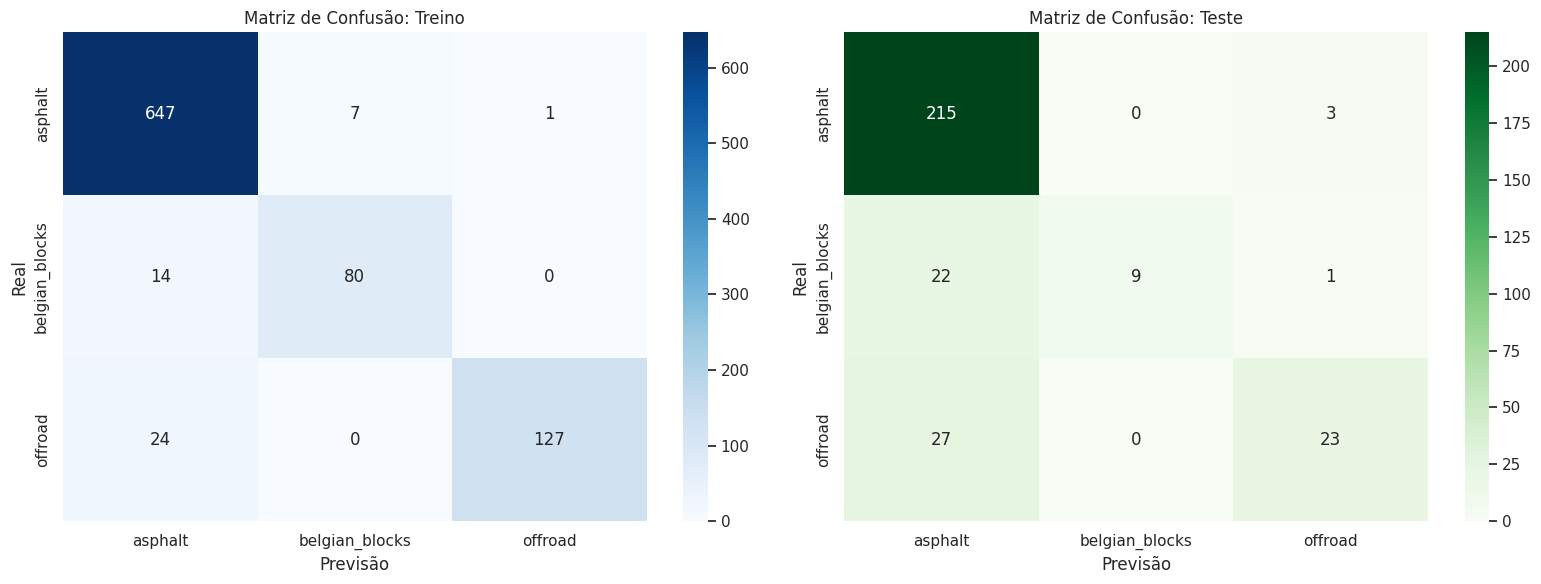

Avaliação: Treino
                precision    recall  f1-score   support

       asphalt       0.94      0.99      0.97       655
belgian_blocks       0.92      0.85      0.88        94
       offroad       0.99      0.84      0.91       151

      accuracy                           0.95       900
     macro avg       0.95      0.89      0.92       900
  weighted avg       0.95      0.95      0.95       900

Avaliação: Teste
                precision    recall  f1-score   support

       asphalt       0.81      0.99      0.89       218
belgian_blocks       1.00      0.28      0.44        32
       offroad       0.85      0.46      0.60        50

      accuracy                           0.82       300
     macro avg       0.89      0.58      0.64       300
  weighted avg       0.84      0.82      0.79       300



In [ ]:
# @title Avaliação Treino vs Teste

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def get_predictions_and_labels(model, dataset):
    all_labels = []
    all_preds = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(all_labels), np.array(all_preds)

y_true_train, y_pred_train = get_predictions_and_labels(model_h1, train)
y_true_test, y_pred_test = get_predictions_and_labels(model_h1, test)

# Métricas
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_test = accuracy_score(y_true_test, y_pred_test)
train_loss, _ = model_h1.evaluate(train, verbose=0)
test_loss, _ = model_h1.evaluate(test, verbose=0)

metrics_names = ['Acurácia', 'Perda (Loss)']
train_metrics = [acc_train, train_loss]
test_metrics = [acc_test, test_loss]

# Gráfico de Aprendizado
x = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

rects1 = ax.bar(x - width/2, train_metrics, width, label='Treino', color='#440154')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Teste', color='#21918c')

ax.set_ylabel('Valor')
ax.set_title('Treino vs. Teste')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Matrizes de Confusão
fig, ax_mat = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Treino
cm_train = confusion_matrix(y_true_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax_mat[0],
            xticklabels=class_names, yticklabels=class_names)
ax_mat[0].set_title('Matriz de Confusão: Treino')
ax_mat[0].set_xlabel('Previsão')
ax_mat[0].set_ylabel('Real')

# Matriz de Teste
cm_test = confusion_matrix(y_true_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax_mat[1],
            xticklabels=class_names, yticklabels=class_names)
ax_mat[1].set_title('Matriz de Confusão: Teste')
ax_mat[1].set_xlabel('Previsão')
ax_mat[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Avaliação de Treino e Teste
print("Avaliação: Treino")
print(classification_report(y_true_train, y_pred_train, target_names=class_names))

print("Avaliação: Teste")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

## Hipótese 2

**1. Hipótese e Motivação:**

O desbalanceamento severo (mais de 70% de "asphalt") induz o modelo a um viés de classificação. A hipótese é que a aplicação de Class Weights durante o treinamento, inversamente proporcionais à frequência das classes, equilibrará o aprendizado. Isso penalizará o modelo mais severamente por erros nas classes minoritárias, forçando-o a aprender as características de textura, mesmo com menos exemplos disponíveis.

**2. O que foi modificado:** Será calculado o dicionário de pesos de classe com base no suporte do treino (asphalt: 655, offroad: 151, belgian_blocks: 94). No método model.fit(), o parâmetro class_weight será utilizado para dar um peso maior para "belgian_blocks" e "offroad".

**3. O que foi observado:**
- A Adoção de Class Weight penalizou mais erros em "belgian_blocks" (peso 3.19) e "offroad" (peso 1.98), comparados com "asphalt" (peso 0.45);
- A acurácia permaneceu igual à Hipótese 1, reflexo do "teto";
- Diferença entre o conjunto de treino e teste.

**4. Interpretação:**
- Overfitting: bons resultados no treino e ruin no teste reflete a dificuldade do modelo aprender a diferença de texturas, principalmente em "belgian_blocks", decorando o conjunto de treino.
- Class Weight ajuda a equilibrar oo gradiente, mas não resolve o problema do desbalanceamento e poucas imagens para classes minoritárias.

A hipótese 2 se mostrou a melhor versão dentre as três testadas. Apesar disso, não se configura como solução definitiva, pois o problema de generaliação aina persiste. Isso indica que próximas testes devem utilizar técnicas de regularização mais eficientes e analisar arquiteturas e modelos mais adequados para o porblema.

In [ ]:
# @title Cálculo de Class Weight

from sklearn.utils import class_weight
import numpy as np

y_integers = np.argmax(y, axis=1)

# Calcula os pesos: as classes com menos amostras recebem pesos maiores
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

class_weights_dict = dict(enumerate(class_weights))

print("Pesos das Classe:")
for idx, weight in class_weights_dict.items():
    print(f" - Classe {class_names[idx]}: {weight:.4f}")

# Melhorando o Modelo
def build_model_h2():
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation_h1, # Usando o augmentation da Hipótese 1
        layers.Lambda(applications.mobilenet_v2.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Pesos das Classe:
 - Classe asphalt: 0.4580
 - Classe belgian_blocks: 3.1915
 - Classe offroad: 1.9868


In [ ]:
# @title Treinamento

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
h2_scores = []

for train_index, val_index in kf.split(X):
    print(f'\nTreinando Fold {fold_no}:')

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model_h2 = build_model_h2()

    # Aplicação da Hipótese 2: parâmetro class_weight
    history_h2 = model_h2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=BATCH_SIZE,
        class_weight=class_weights_dict, # Dicionário de Pesos
        verbose=1
    )

    scores = model_h2.evaluate(X_val, y_val, verbose=0)
    h2_scores.append(scores[1])
    print(f'Acurácia Fold {fold_no} (H2): {scores[1]*100:.2f}%')
    fold_no += 1

print(f'\nResultado Médio H2: {np.mean(h2_scores)*100:.2f}%')


Treinando Fold 1:
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.4778 - loss: 1.1115 - val_accuracy: 0.6500 - val_loss: 0.7644
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7181 - loss: 0.5184 - val_accuracy: 0.8889 - val_loss: 0.3934
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8333 - loss: 0.3561 - val_accuracy: 0.9278 - val_loss: 0.2387
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8458 - loss: 0.3140 - val_accuracy: 0.9444 - val_loss: 0.1825
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8444 - loss: 0.2999 - val_accuracy: 0.9389 - val_loss: 0.2085
Acurácia Fold 1 (H2): 93.89%

Treinando Fold 2:
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5222 - loss: 1.0377 - val_accuracy: 0.8500 - val_loss: 0.5174
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7347 - loss: 0.5312 - val_accuracy: 0.9389 - val_loss: 0.2865
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accurac

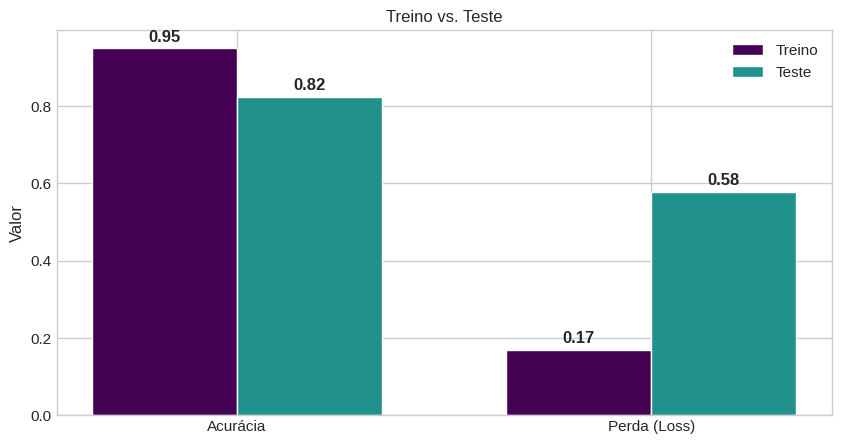

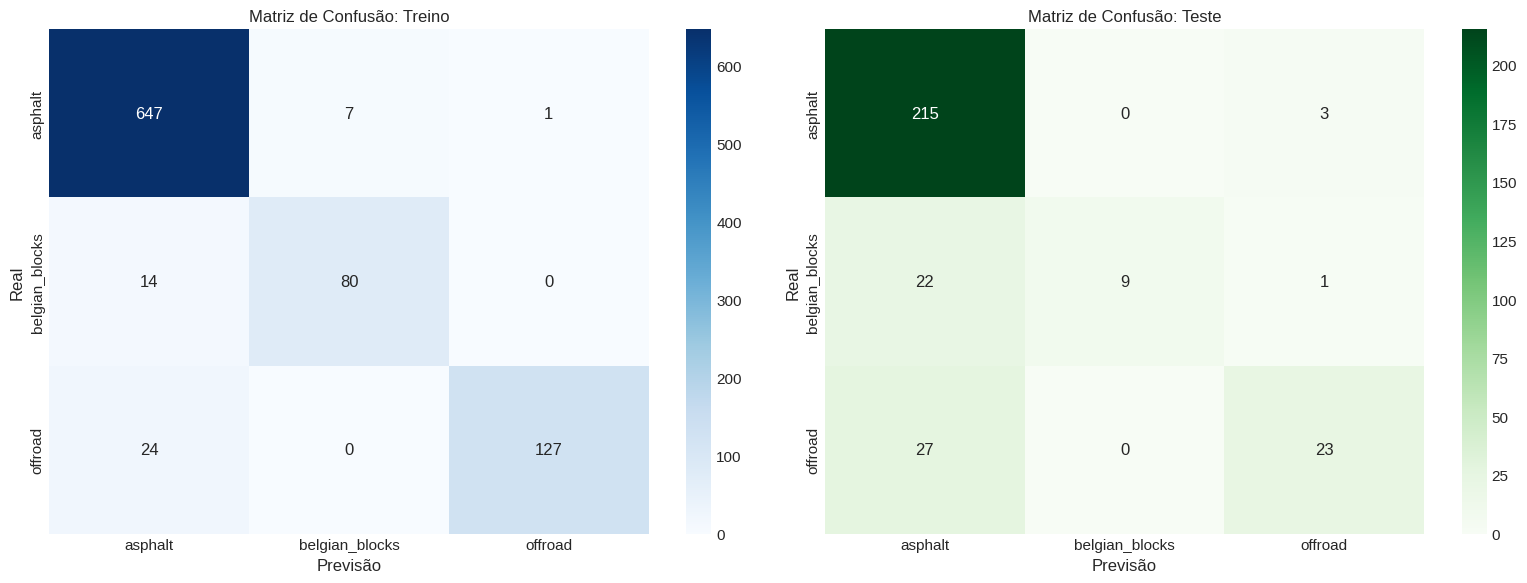

Avaliação: Treino
                precision    recall  f1-score   support

       asphalt       0.94      0.99      0.97       655
belgian_blocks       0.92      0.85      0.88        94
       offroad       0.99      0.84      0.91       151

      accuracy                           0.95       900
     macro avg       0.95      0.89      0.92       900
  weighted avg       0.95      0.95      0.95       900

Avaliação: Teste
                precision    recall  f1-score   support

       asphalt       0.81      0.99      0.89       218
belgian_blocks       1.00      0.28      0.44        32
       offroad       0.85      0.46      0.60        50

      accuracy                           0.82       300
     macro avg       0.89      0.58      0.64       300
  weighted avg       0.84      0.82      0.79       300



In [ ]:
# @title Avaliação Treino vs Teste

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def get_predictions_and_labels(model, dataset):
    all_labels = []
    all_preds = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(all_labels), np.array(all_preds)

y_true_train, y_pred_train = get_predictions_and_labels(model_h1, train)
y_true_test, y_pred_test = get_predictions_and_labels(model_h1, test)

# Métricas
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_test = accuracy_score(y_true_test, y_pred_test)
train_loss, _ = model_h1.evaluate(train, verbose=0)
test_loss, _ = model_h1.evaluate(test, verbose=0)

metrics_names = ['Acurácia', 'Perda (Loss)']
train_metrics = [acc_train, train_loss]
test_metrics = [acc_test, test_loss]

# Gráfico de Aprendizado
x = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

rects1 = ax.bar(x - width/2, train_metrics, width, label='Treino', color='#440154')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Teste', color='#21918c')

ax.set_ylabel('Valor')
ax.set_title('Treino vs. Teste')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Matrizes de Confusão
fig, ax_mat = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Treino
cm_train = confusion_matrix(y_true_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax_mat[0],
            xticklabels=class_names, yticklabels=class_names)
ax_mat[0].set_title('Matriz de Confusão: Treino')
ax_mat[0].set_xlabel('Previsão')
ax_mat[0].set_ylabel('Real')

# Matriz de Teste
cm_test = confusion_matrix(y_true_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax_mat[1],
            xticklabels=class_names, yticklabels=class_names)
ax_mat[1].set_title('Matriz de Confusão: Teste')
ax_mat[1].set_xlabel('Previsão')
ax_mat[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Avaliação de Treino e Teste
print("Avaliação: Treino")
print(classification_report(y_true_train, y_pred_train, target_names=class_names))

print("Avaliação: Teste")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

**Análise Crítica e Passos Futuros:**

- Onde o modelo foi bem: A detecção da classe "asphalt" foi consistentemente superior, atingindo um recall de 99% após os ajustes de brilho e pesos. A estratégia de Transfer Learning com a MobileNetV2 foi eficaz para extrair características iniciais, e o ajuste da Hipótese 1 trouxe melhora contra variações extremas de luminosidade, estabilizando a performance na classe majoritária.  

- Onde o modelo falhou: O modelo apresentou dificuldades na generalização das classes minoritárias, especialmente em "belgian_blocks", onde o recall permaneceu baixo (28%) no conjunto de teste. Apesar de apresentar precisão perfeita (1.00), o modelo falha em detectar a classe quando as condições visuais são diferentes do treino, indicando que a rede "decorou" texturas específicas em vez de aprender o conceito da via.  

- Limitações da solução atual: A principal limitação é o overfitting causado pela baixa diversidade visual das amostras minoritárias no dataset original. O uso de pesos de classe (Hipótese 2) ajudou no equilíbrio, mas não substituiu a necessidade de uma maior variedade de exemplos reais de terra e blocos de pedra para capturar as características dessas superfícies.  

- Passos Futuros: Caso houvesse mais tempo para o desenvolvimento:
1. Técnicas de Balanceamento: Implementação de técnicas de sobreamostragem sintética como o SMOTE no espaço de características ou o uso de Focal Loss para focar o aprendizado em exemplos difíceis.  
2. Refinamento Arquitetural: Teste de arquiteturas focadas espaço para destacar micro-texturas.

**Uso de LLMs:**

Uso da ferramenta Gemini:
- Refinamento de Código.

- Auxílio na rorganização dos entregáveis para garantir que a comunicação das decisões técnicas fosse clara e objetiva.